In [81]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Thu Jul 18 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [83]:
with open('/home/yaning/Documents/Discounting/results/array_future.pkl', 'rb') as f:
    data = pickle.load(f)

In [84]:
data = torch.tensor(data)

In [85]:
data = data.to(device)

In [86]:
data.shape

torch.Size([2, 30, 118, 6])

In [87]:
data = data[1]

In [ ]:
def model(data):
    num_params = 4
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        sigma_rate = torch.exp(locs[:,0]).unsqueeze(-1).expand(-1, num_trials)
        exp_a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        exp_b = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,3]).unsqueeze(-1).expand(-1, num_trials)

        sigma_combine = sigma_rate/(1+exp_b*torch.exp(-exp_a*data[:,:,2]))

        e_mean = (data[:,:,3])/(sigma_combine + 1)
        sum = e_mean + torch.tensor(20., device=device)

        softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [89]:
def guide(data):
    num_params = 4
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 867.05: 100%|██████████████████████████████████████████████████████████████| 5000/5000 [00:50<00:00, 99.78it/s]


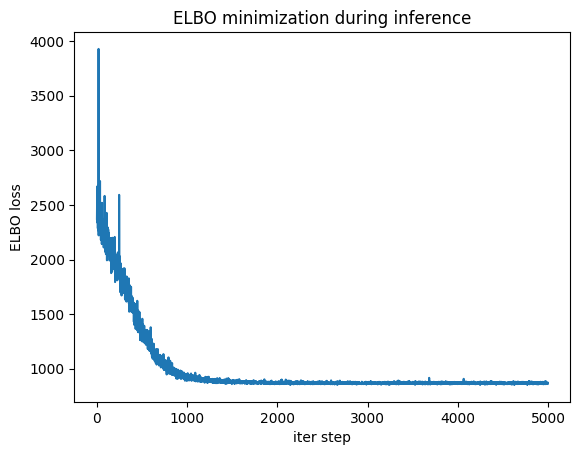

In [90]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [91]:
for i in loss:
    print(i.numpy())

2373.1357
2495.9688
2551.7454
2665.1592
2390.984
2625.9744
2337.7583
2526.8494
2674.4229
2508.4287
2285.6675
2385.6006
2597.6797
2267.5637
2542.771
2287.6206
2358.5493
2277.533
3929.2642
2221.5771
2424.6672
2394.2373
2532.664
2417.6086
2476.3948
2291.371
2290.164
2277.1494
2357.5388
2271.685
2304.3237
2324.2515
2302.9712
2223.5085
2719.0735
2262.8767
2397.4136
2372.1272
2265.484
2230.324
2386.5698
2353.1504
2376.8887
2258.1724
2178.9683
2342.7668
2281.1235
2464.4304
2293.0178
2310.675
2239.3464
2289.1086
2332.9956
2356.5278
2142.1284
2304.9685
2519.627
2363.8738
2265.5916
2198.6023
2142.8972
2260.587
2369.843
2193.8567
2198.974
2265.8555
2188.7302
2219.9417
2191.1726
2288.6426
2279.0366
2243.7007
2239.3828
2143.1592
2251.4475
2110.876
2249.1577
2189.154
2299.5012
2214.71
2149.369
2210.2622
2276.785
2172.5972
2163.1382
2582.7974
2248.0923
2233.596
2263.4712
2230.5896
2264.0977
2265.626
2143.9163
2069.2632
2170.593
2105.6401
2290.4514
2276.8442
2221.9668
2211.9382
2049.1665
2204.5308
214

In [92]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [93]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [94]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [95]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/future_indiv.csv", index=False)

In [96]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/future_mean.csv", index=False)

In [97]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/future.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)